# Research Reproducibility Template

**Category:** Risk Engineering  
**Project ID:** `risk_02_reproducibility`  

MLflow experiment tracking, DVC data versioning, Hydra config management, and statistical result validation


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"n_splits": 5}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
                   n_splits: 5


Data shape: (752, 15)
Date range: 2022-01-03 to 2024-12-30

Summary statistics:
Ticker       GLD       SPY       TLT
count   752.0000  752.0000  752.0000
mean    189.8027  444.5639   92.7703
std      26.2586   68.8578   10.2597
min     151.2300  341.1820   75.1242
25%     171.2675  390.6235   86.1116
50%     181.8700  423.9385   90.5387
75%     211.0475  500.4846   95.1490
max     257.5000  598.7401  124.8801


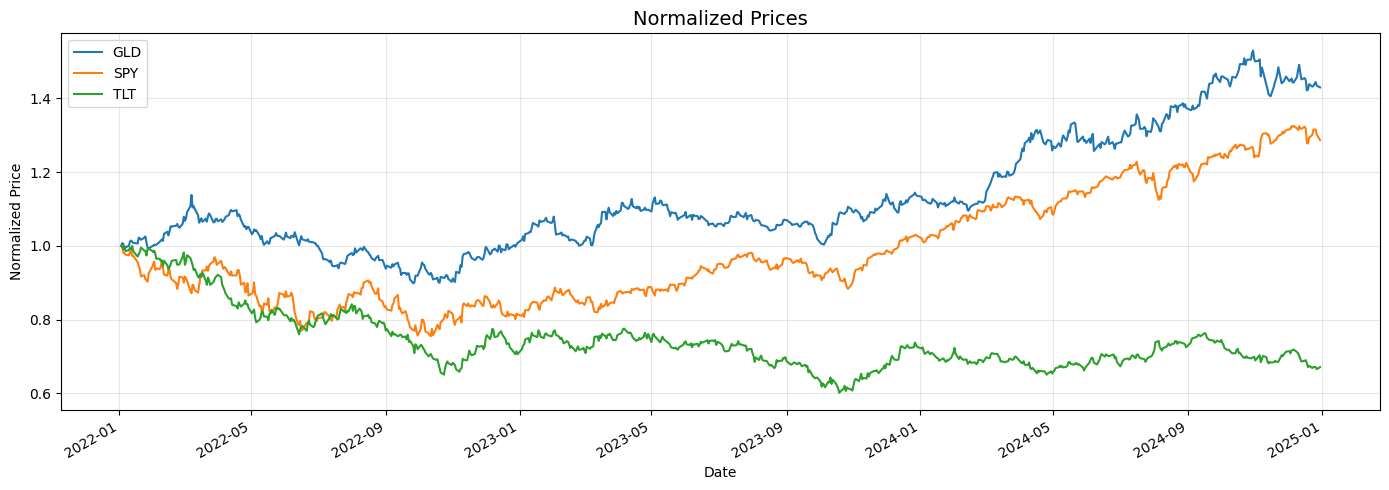

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = ['SPY', 'TLT', 'GLD']
data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

# Handle MultiIndex columns (yfinance >=0.2.x returns MultiIndex for multiple tickers)
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"]
else:
    close = data[["Close"]] if isinstance(tickers, list) else data["Close"].to_frame()

# Drop rows where all Close values are NaN
close = close.dropna(how="all")
data = data.loc[close.index]

if close.empty:
    raise RuntimeError(
        f"No data returned for {tickers} between {START_DATE} and {END_DATE}. "
        "Check ticker symbols and date range."
    )

print(f"Data shape: {data.shape}")
print(f"Date range: {close.index[0].strftime('%Y-%m-%d')} to {close.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSummary statistics:")
print(close.describe().round(4))

# Price chart
fig, ax = plt.subplots(figsize=(14, 5))
(close / close.iloc[0]).plot(ax=ax, linewidth=1.5)
ax.set_title("Normalized Prices", fontsize=14)
ax.set_ylabel("Normalized Price")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Walk-Forward Cross-Validation & Statistical Significance

Walk-Forward CV: 5 folds, embargo=10 days
Fold size: 146 days

  Fold 1: Sharpe=+0.735, Ann. Return=+9.14%, Days=146
  Fold 2: Sharpe=+1.298, Ann. Return=+18.78%, Days=146
  Fold 3: Sharpe=-1.029, Ann. Return=-9.73%, Days=146
  Fold 4: Sharpe=+1.689, Ann. Return=+16.30%, Days=146
  Fold 5: Sharpe=-0.377, Ann. Return=-3.73%, Days=146

--- Statistical Significance ---
Full-sample Sharpe: +0.549
Bootstrap p-value (Sharpe > 0): 0.8246
95% CI: [-0.575, +1.695]
Deflated Sharpe Ratio: +0.537
Skewness: 0.212, Kurtosis: 4.861


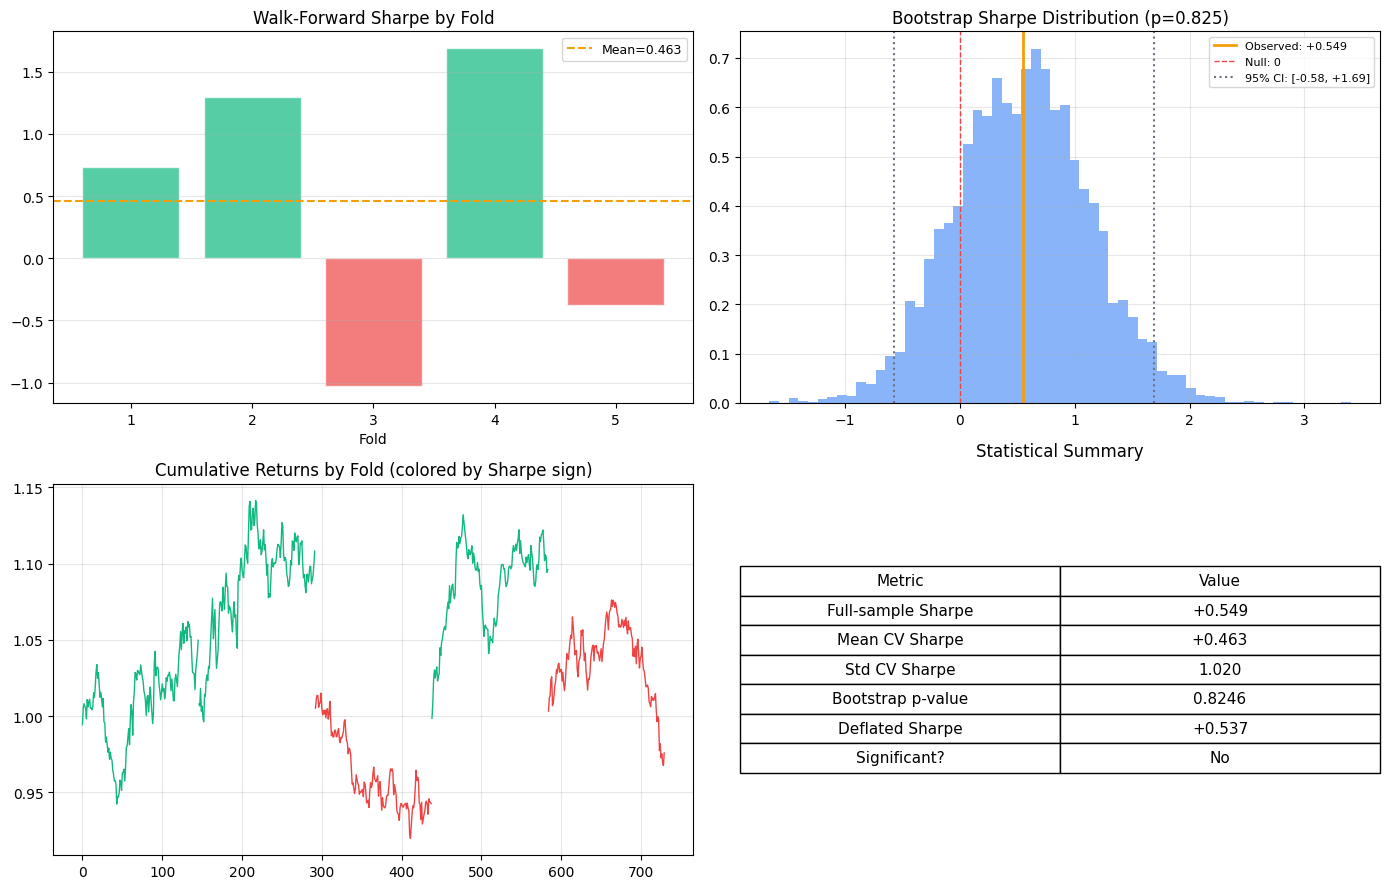

In [4]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

returns_df = close.pct_change().dropna()
if returns_df.ndim > 1:
    returns_s = returns_df.mean(axis=1)
else:
    returns_s = returns_df

n = len(returns_s)
n_splits = PARAMS.get("n_splits", 5)
embargo = PARAMS.get("embargo_days", 10)

# --- Walk-Forward Cross-Validation with Purging + Embargo ---
# Simple momentum strategy for testing
lookback = 20
signal = returns_s.rolling(lookback).mean().shift(1)
strat_ret = signal.apply(np.sign) * returns_s
strat_ret = strat_ret.dropna()

fold_size = len(strat_ret) // n_splits
fold_sharpes = []
fold_returns = []

print(f"Walk-Forward CV: {n_splits} folds, embargo={embargo} days")
print(f"Fold size: {fold_size} days\n")

for fold in range(n_splits):
    test_start = fold * fold_size
    test_end = min(test_start + fold_size, len(strat_ret))
    # Train: everything except test + embargo buffer
    train_mask = np.ones(len(strat_ret), dtype=bool)
    purge_start = max(test_start - embargo, 0)
    purge_end = min(test_end + embargo, len(strat_ret))
    train_mask[purge_start:purge_end] = False

    test_ret = strat_ret.iloc[test_start:test_end]
    if len(test_ret) < 10:
        continue

    sr = test_ret.mean() / test_ret.std() * np.sqrt(252) if test_ret.std() > 0 else 0
    fold_sharpes.append(sr)
    fold_returns.append(test_ret.mean() * 252)
    print(f"  Fold {fold+1}: Sharpe={sr:+.3f}, Ann. Return={test_ret.mean()*252:+.2%}, Days={len(test_ret)}")

# --- Bootstrap Sharpe Significance Test ---
n_bootstrap = 5000
rng = np.random.default_rng(SEED)
full_sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(252) if strat_ret.std() > 0 else 0

bootstrap_sharpes = []
for _ in range(n_bootstrap):
    sample = rng.choice(strat_ret.values, size=len(strat_ret), replace=True)
    bs_sr = np.mean(sample) / np.std(sample) * np.sqrt(252) if np.std(sample) > 0 else 0
    bootstrap_sharpes.append(bs_sr)

bootstrap_sharpes = np.array(bootstrap_sharpes)
p_value = (bootstrap_sharpes <= 0).mean()
ci_lower = np.percentile(bootstrap_sharpes, 2.5)
ci_upper = np.percentile(bootstrap_sharpes, 97.5)

# --- Deflated Sharpe Ratio (simplified) ---
# Adjusts for multiple testing: DSR = Sharpe * sqrt(n) / sqrt(1 + skew*sharpe/6 + (kurt-3)*sharpe^2/24)
from scipy.stats import norm
skew = float(pd.Series(strat_ret).skew())
kurt = float(pd.Series(strat_ret).kurtosis()) + 3  # excess -> raw
dsr_denom = np.sqrt(1 + skew * full_sharpe / 6 + (kurt - 3) * full_sharpe**2 / 24)
dsr = full_sharpe / max(dsr_denom, 1e-9)

print(f"\n--- Statistical Significance ---")
print(f"Full-sample Sharpe: {full_sharpe:+.3f}")
print(f"Bootstrap p-value (Sharpe > 0): {1 - p_value:.4f}")
print(f"95% CI: [{ci_lower:+.3f}, {ci_upper:+.3f}]")
print(f"Deflated Sharpe Ratio: {dsr:+.3f}")
print(f"Skewness: {skew:.3f}, Kurtosis: {kurt:.3f}")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Walk-forward Sharpe by fold
colors_bar = ["#10b981" if s > 0 else "#ef4444" for s in fold_sharpes]
axes[0, 0].bar(range(1, len(fold_sharpes)+1), fold_sharpes, color=colors_bar, alpha=0.7, edgecolor="white")
axes[0, 0].axhline(np.mean(fold_sharpes), color="#f59e0b", linestyle="--", label=f"Mean={np.mean(fold_sharpes):.3f}")
axes[0, 0].set_title("Walk-Forward Sharpe by Fold")
axes[0, 0].set_xlabel("Fold")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3, axis="y")

# Bootstrap Sharpe distribution
axes[0, 1].hist(bootstrap_sharpes, bins=60, color="#3b82f6", alpha=0.6, edgecolor="none", density=True)
axes[0, 1].axvline(full_sharpe, color="#f59e0b", linewidth=2, label=f"Observed: {full_sharpe:+.3f}")
axes[0, 1].axvline(0, color="#ef4444", linewidth=1, linestyle="--", label="Null: 0")
axes[0, 1].axvline(ci_lower, color="#6b7280", linestyle=":", label=f"95% CI: [{ci_lower:+.2f}, {ci_upper:+.2f}]")
axes[0, 1].axvline(ci_upper, color="#6b7280", linestyle=":")
axes[0, 1].set_title(f"Bootstrap Sharpe Distribution (p={1-p_value:.3f})")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# Cumulative strategy return per fold
offset = 0
for fold in range(min(n_splits, len(fold_sharpes))):
    test_start = fold * fold_size
    test_end = min(test_start + fold_size, len(strat_ret))
    fold_eq = (1 + strat_ret.iloc[test_start:test_end]).cumprod()
    color = "#10b981" if fold_sharpes[fold] > 0 else "#ef4444"
    axes[1, 0].plot(range(offset, offset + len(fold_eq)), fold_eq.values, linewidth=1, color=color)
    offset += len(fold_eq)
axes[1, 0].set_title("Cumulative Returns by Fold (colored by Sharpe sign)")
axes[1, 0].grid(True, alpha=0.3)

# Summary table
summary_data = [
    ["Full-sample Sharpe", f"{full_sharpe:+.3f}"],
    ["Mean CV Sharpe", f"{np.mean(fold_sharpes):+.3f}"],
    ["Std CV Sharpe", f"{np.std(fold_sharpes):.3f}"],
    ["Bootstrap p-value", f"{1-p_value:.4f}"],
    ["Deflated Sharpe", f"{dsr:+.3f}"],
    ["Significant?", "Yes" if (1-p_value) < 0.05 else "No"],
]
axes[1, 1].axis("off")
table = axes[1, 1].table(cellText=summary_data, colLabels=["Metric", "Value"],
                          loc="center", cellLoc="center")
table.auto_set_font_size(False); table.set_fontsize(11)
table.scale(1, 1.5)
axes[1, 1].set_title("Statistical Summary", fontsize=12, pad=20)

plt.tight_layout()
plt.show()


## Strategy Backtest

In [5]:
import pandas as pd, numpy as np

# Use the momentum strategy returns as the equity curve
strategy_returns_raw = strat_ret
equity_curve = (1 + strategy_returns_raw).cumprod()

returns_s_aligned = returns_s.loc[equity_curve.index] if hasattr(returns_s, 'loc') else returns_s
benchmark_equity = (1 + returns_s_aligned).cumprod()

print(f"Backtest: {equity_curve.index[0].strftime('%Y-%m-%d')} to {equity_curve.index[-1].strftime('%Y-%m-%d')}")


Backtest: 2022-02-02 to 2024-12-30


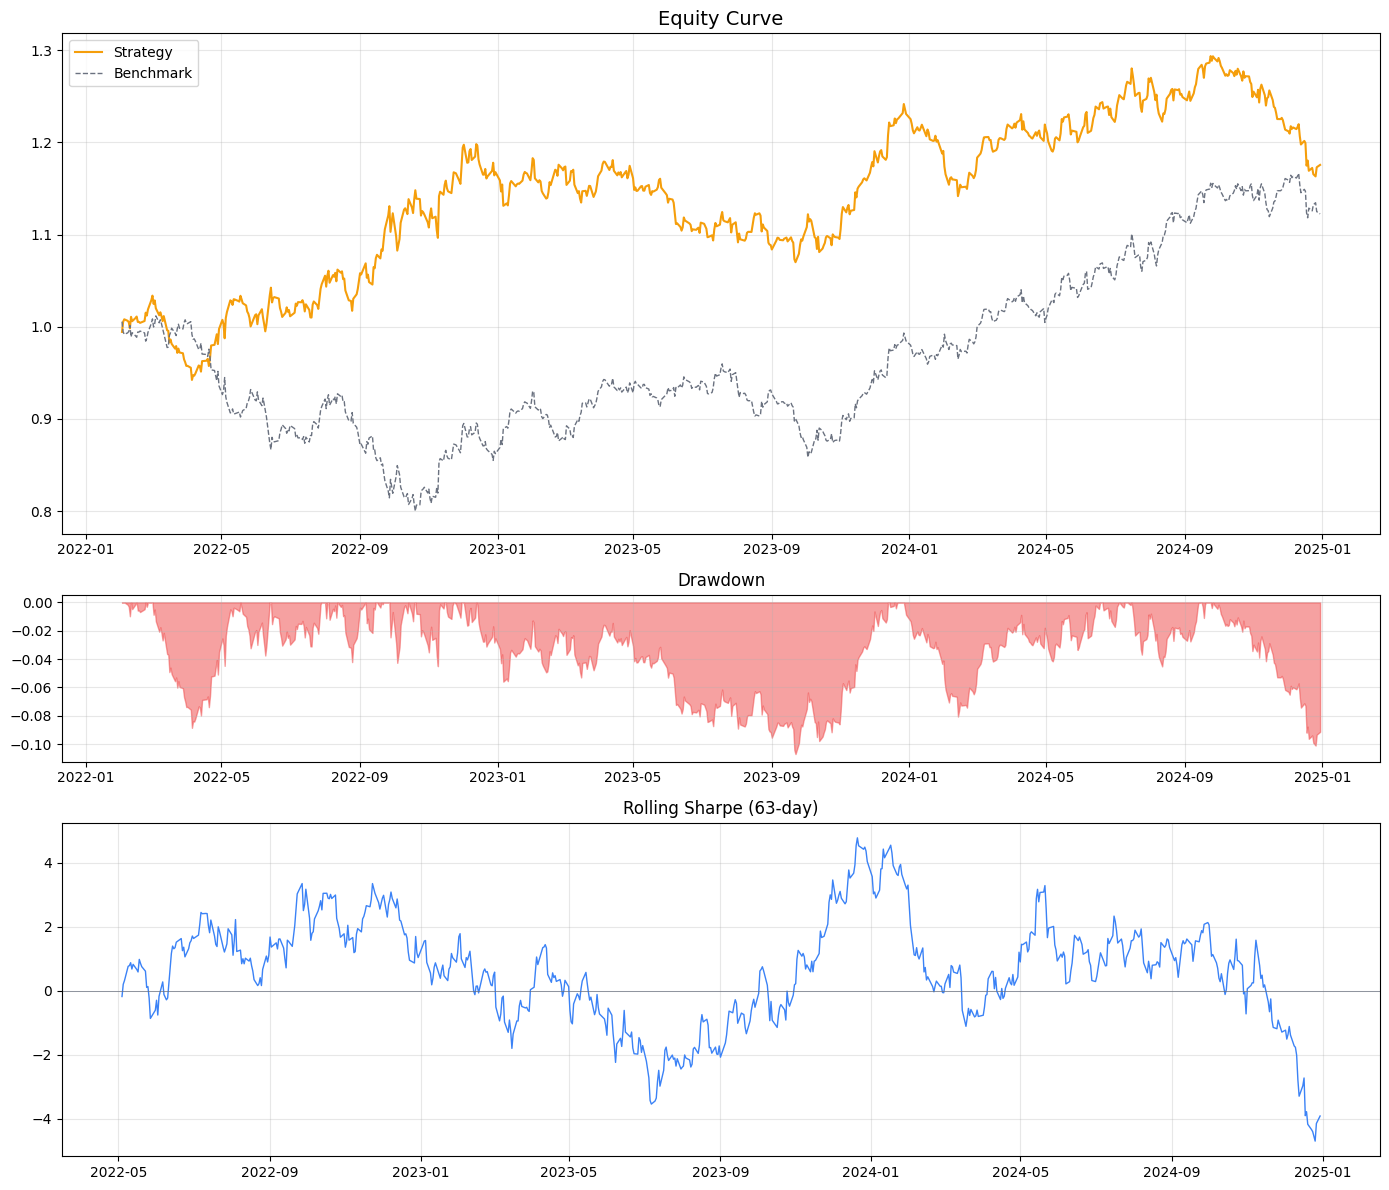

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: +18.23%
                       cagr: +5.95%
             annualized_vol: +11.34%
               sharpe_ratio: 0.5663
              sortino_ratio: 0.9125
               calmar_ratio: 0.5564
               max_drawdown: -10.69%
                   win_rate: +51.37%
              profit_factor: 1.0971
               total_trades: 730


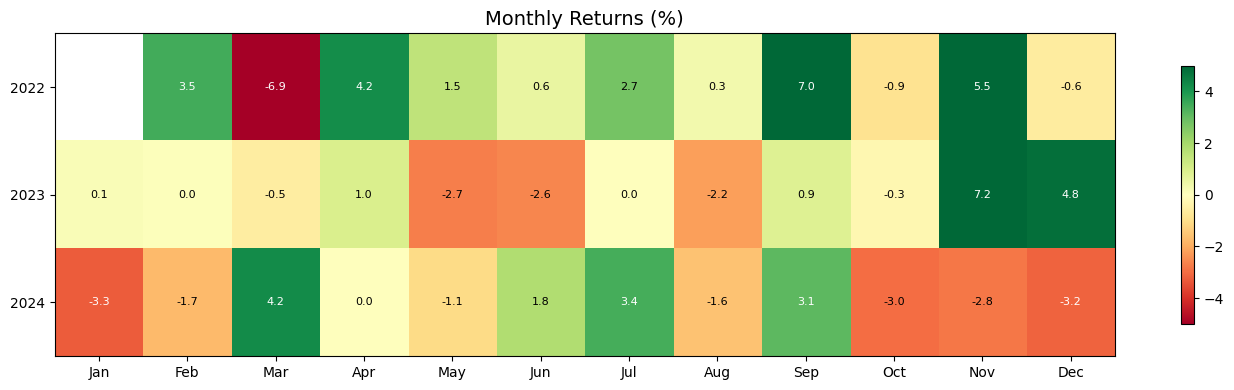

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Monthly returns heatmap — requires DatetimeIndex; skipped for synthetic/HFT data
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
except Exception:
    print("Monthly heatmap skipped: equity curve does not have a DatetimeIndex (synthetic data).")
    monthly = None

if monthly is not None:
    monthly_df = pd.DataFrame({
        "year": monthly.index.year,
        "month": monthly.index.month,
        "return": monthly.values,
    })
    pivot = monthly_df.pivot(index="year", columns="month", values="return")
    pivot = pivot.reindex(columns=range(1, 13))  # ensure all 12 months present
    pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(pivot.values * 100, cmap="RdYlGn", aspect="auto", vmin=-5, vmax=5)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Monthly Returns (%)", fontsize=14)

    # Text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < 0.03 else "white")

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


In [9]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "risk_02_reproducibility",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Research Reproducibility Template

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
